# **Modelo Predictor de Cancer de Tiroides**
Este notebook realiza un análisis exploratorio y construcción de un modelo de Machine Learning para predecir la recurrencia de cáncer de tiroides basándose en características clínicas, patológicas y de tratamiento de pacientes.

### Estructura del dataset
El dataset contiene **17 características** asociadas a pacientes con cáncer de tiroides. Estas características fueron registradas en el momento del diagnóstico inicial y se verifica si los pacientes las mantienen o desarrollan cambios después del tratamiento.

| # | Característica | Tipo | Descripción |
|---|---|---|---|
| 1 | **Age** | Numérica | Edad del paciente al diagnóstico |
| 2 | **Gender** | Categórica | Género del paciente (M/F) |
| 3 | **Smoking** | Categórica | Estado actual de fumador |
| 4 | **Hx Smoking** | Categórica | Historial de fumar |
| 5 | **Hx Radiotherapy** | Categórica | Antecedentes de radioterapia |
| 6 | **Thyroid Function** | Categórica | Estado de función tiroidea |
| 7 | **Physical Examination** | Categórica | Hallazgos del examen físico |
| 8 | **Adenopathy** | Categórica | Presencia de linfadenopatía en cuello |
| 9 | **Pathology** | Categórica | Tipo histológico de cáncer (biópsia) |
| 10 | **Focality** | Categórica | Unifocal vs Multifocal |
| 11 | **Risk** | Categórica | Categoría de riesgo del cáncer |
| 12 | **T** | Categórica | Clasificación TNM - Tumor (tamaño/invasión) |
| 13 | **N** | Categórica | Clasificación TNM - Nodos (ganglios linfáticos) |
| 14 | **M** | Categórica | Clasificación TNM - Metástasis |
| 15 | **Stage** | Categórica | Estadio general del cáncer |
| 16 | **Response** | Categórica | Respuesta al tratamiento |
| 17 | **Recurred** | Categórica | ¿Hubo recurrencia? |

La variable objetivo es **Recurrred**, indica si el cáncer de tiroides recurrió después del tratamiento inicial (Sí/No)

### **Fase 1 - Carga y exploración inicial de datos (EDA)**

#### Importación de liberias

In [77]:
# Data manipulation
import pandas as pd
import numpy as np
import time 
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
 
# Machine Learning - Scores
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from category_encoders import BinaryEncoder


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

#### Cargar dataset 

In [33]:
df_thyroid = pd.read_csv('data/Thyroid_Diff.csv')

#### Exploración inicial

In [34]:
df_thyroid.shape

(383, 17)

In [35]:
df_thyroid.head(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


In [36]:
df_thyroid.tail(5)

,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
378,72,M,Yes,Yes,Yes,Euthyroid,Single nodular goiter-right,Right,Papillary,Uni-Focal,High,T4b,N1b,M1,IVB,Biochemical Incomplete,Yes
379,81,M,Yes,No,Yes,Euthyroid,Multinodular goiter,Extensive,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
380,72,M,Yes,Yes,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M1,IVB,Structural Incomplete,Yes
381,61,M,Yes,Yes,Yes,Clinical Hyperthyroidism,Multinodular goiter,Extensive,Hurthel cell,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes
382,67,M,Yes,No,No,Euthyroid,Multinodular goiter,Bilateral,Papillary,Multi-Focal,High,T4b,N1b,M0,IVA,Structural Incomplete,Yes


#### Analisis inicial

In [37]:
df_thyroid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Age                   383 non-null    int64 
 1   Gender                383 non-null    object
 2   Smoking               383 non-null    object
 3   Hx Smoking            383 non-null    object
 4   Hx Radiothreapy       383 non-null    object
 5   Thyroid Function      383 non-null    object
 6   Physical Examination  383 non-null    object
 7   Adenopathy            383 non-null    object
 8   Pathology             383 non-null    object
 9   Focality              383 non-null    object
 10  Risk                  383 non-null    object
 11  T                     383 non-null    object
 12  N                     383 non-null    object
 13  M                     383 non-null    object
 14  Stage                 383 non-null    object
 15  Response              383 non-null    ob

Con esta exploración inicial identificamos que el dataset contiene **383 registros** y **16 características** más la variable objetivo. El dataset no presenta valores faltantes; sin embargo, destaca la predominancia de **variables categóricas**, lo que requiere preprocesamiento mediante técnicas de encoding para el modelado posterior.

In [38]:
df_thyroid.describe()

,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000


El dataset contiene una única variable numérica: **Edad (Age)**. El análisis revela que:

- **Edad promedio**: 40.9 años, indicando que el cáncer de tiroides afecta principalmente a adultos en edades productivas
- **Rango de edades**: 15 a 82 años, demostrando que la enfermedad puede presentarse desde adolescentes hasta adultos mayores
- **Distribución central**: El 50% de los pacientes tienen entre 29 y 51 años (rango intercuartílico), sugiriendo una concentración en adultos jóvenes a mediana edad
- **Variabilidad**: Desviación estándar de 15.1 años indica una dispersión moderada de edades alrededor de la media

In [39]:
df_thyroid.describe(include='object')

,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
count,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383,383
unique,2,2,2,2,5,5,6,4,2,3,7,3,2,5,4,2
top,F,No,No,No,Euthyroid,Multinodular goiter,No,Papillary,Uni-Focal,Low,T2,N0,M0,I,Excellent,No
freq,312,334,355,376,332,140,277,287,247,249,151,268,365,333,208,275


Dada la ausencia de variables numéricas adicionales, se realiza un análisis detallado de las 16 características categóricas:

**Demografía y Factores de Riesgo:**
- **Género**: Predominio de mujeres (312/383 = 81%), consistente con la epidemiología del cáncer de tiroides
- **Tabaquismo actual (Smoking)**: 334/383 pacientes no fuman (87%), sugiriendo que el tabaquismo actual no es un factor predominante en esta cohorte
- **Historial de tabaquismo (Hx Smoking)**: 355/383 nunca fumaron (93%), reforzando que el tabaco no parece ser un factor de riesgo determinante

**Características Clínicas:**
- **Función tiroidea**: El estado Euthyroid predomina (332/383 = 87%), indicando que la mayoría de pacientes mantienen función tiroidea normal
- **Patología**: Cáncer papilar es el tipo histológico más frecuente (287/383 = 75%), el tipo más común y con mejor pronóstico
- **Categoría de riesgo**: 249/383 pacientes (65%) clasificados como bajo riesgo, sugiriendo una cohorte con pronóstico generalmente favorable

**Variable Objetivo - Recurrencia:**
- **Sin recurrencia**: 275/383 (72%)
- **Con recurrencia**: 108/383 (28%)
- **Hipótesis inicial**: A pesar que la mayoría no fuman, se observa una tasa de recurrencia considerable (28%), sugiriendo que factores distintos al tabaquismo (como tipo histológico, estadio TNM o respuesta al tratamiento) pueden ser más influyentes en la recurrencia

#### Tratamiento de duplicados y nulos

In [40]:
df_thyroid.duplicated().sum()

np.int64(19)

In [41]:
df_thyroid[df_thyroid.duplicated(keep=False)]


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
22,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
32,36,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
38,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
40,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
61,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
66,35,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
67,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No
69,51,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Papillary,Uni-Focal,Low,T1b,N0,M0,I,Excellent,No


In [42]:
df_thyroid = df_thyroid.drop_duplicates()

In [43]:
df_thyroid.duplicated().sum()


np.int64(0)

In [45]:
df_thyroid.shape

(364, 17)

Se identificaron y eliminaron 19 registros completamente duplicados del dataset, manteniendo la primera ocurrencia de cada uno. El dataset resultante contiene **364 registros únicos**, eliminando redundancia que podría afectar el modelado.

#### Inconsistencias de formato

In [44]:
object_cols = df_thyroid.select_dtypes(include='object').columns

resumen_object = pd.DataFrame({
    'Non-Null Count': df_thyroid[object_cols].notnull().sum(),
    'Unique': df_thyroid[object_cols].nunique(),
    'Unique Values': [df_thyroid[col].unique().tolist() for col in object_cols]
})

resumen_object


,Non-Null Count,Unique,Unique Values
Gender,364,2,"[F, M]"
Smoking,364,2,"[No, Yes]"
Hx Smoking,364,2,"[No, Yes]"
Hx Radiothreapy,364,2,"[No, Yes]"
Thyroid Function,364,5,"[Euthyroid, Clinical Hyperthyroidism, Clinical..."
Physical Examination,364,5,"[Single nodular goiter-left, Multinodular goit..."
Adenopathy,364,6,"[No, Right, Extensive, Left, Bilateral, Poster..."
Pathology,364,4,"[Micropapillary, Papillary, Follicular, Hurthe..."
Focality,364,2,"[Uni-Focal, Multi-Focal]"
Risk,364,3,"[Low, Intermediate, High]"


Se verificó la consistencia de los datos analizando los valores únicos en cada columna. No se encontraron inconsistencias de formato o tipeo; todos los valores categóricos están escritos de forma uniforme y consistente, sin variaciones en mayúsculas/minúsculas o espacios inadecuados.

### Outliers

In [56]:
# Cálculo de IQR para detectar outliers en Age
q1 = df_thyroid['Age'].quantile(0.25)
q3 = df_thyroid['Age'].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_thyroid[(df_thyroid['Age'] < lower_bound) | (df_thyroid['Age'] > upper_bound)]

print(f"Q1: {q1}")
print(f"Q3: {q3}")
print(f"IQR: {iqr}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"Number of outliers: {outliers.shape[0]}")


Q1: 30.0
Q3: 52.0
IQR: 22.0
Lower bound: -3.0
Upper bound: 85.0
Number of outliers: 0


In [58]:
# Paleta de colores personalizada
color_palette = ['#440154', '#3B528B', '#21918C', '#5EC962', '#FDE725']

# Para que Seaborn la use por defecto en todos los gráficos
sns.set_palette(color_palette)

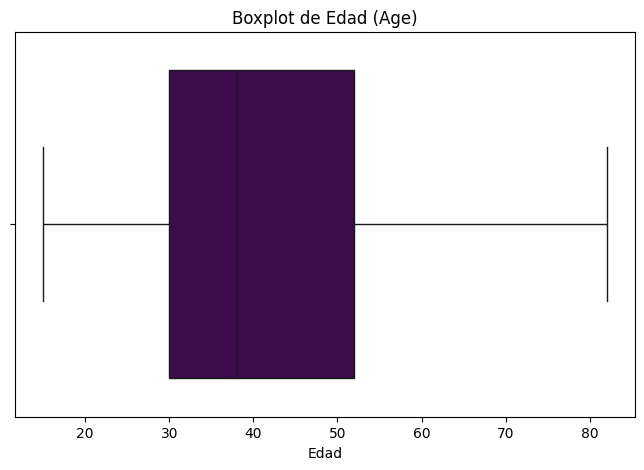

In [59]:
# Boxplot de la edad
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_thyroid['Age'])
plt.title('Boxplot de Edad (Age)')
plt.xlabel('Edad')
plt.show()



El análisis de IQR para la variable Age no identificó valores atípicos (outliers). Todos los registros se encuentran dentro del rango esperado (entre el límite inferior y superior calculado), lo cual es consistente con lo observado en el boxplot, confirmando que la distribución de edades no presenta valores extremos.

#### Gráficos EDA

Para identificar cuáles variables son más importantes para hacer el EDA, se calcula la relación que tienen con la variable objetivo (Recurrencia). Se seleccionan las 5 variables con mayor relación, puesto que son las de mayor influencia. De esta forma, nos enfocamos en las características que realmente importan para el modelo.

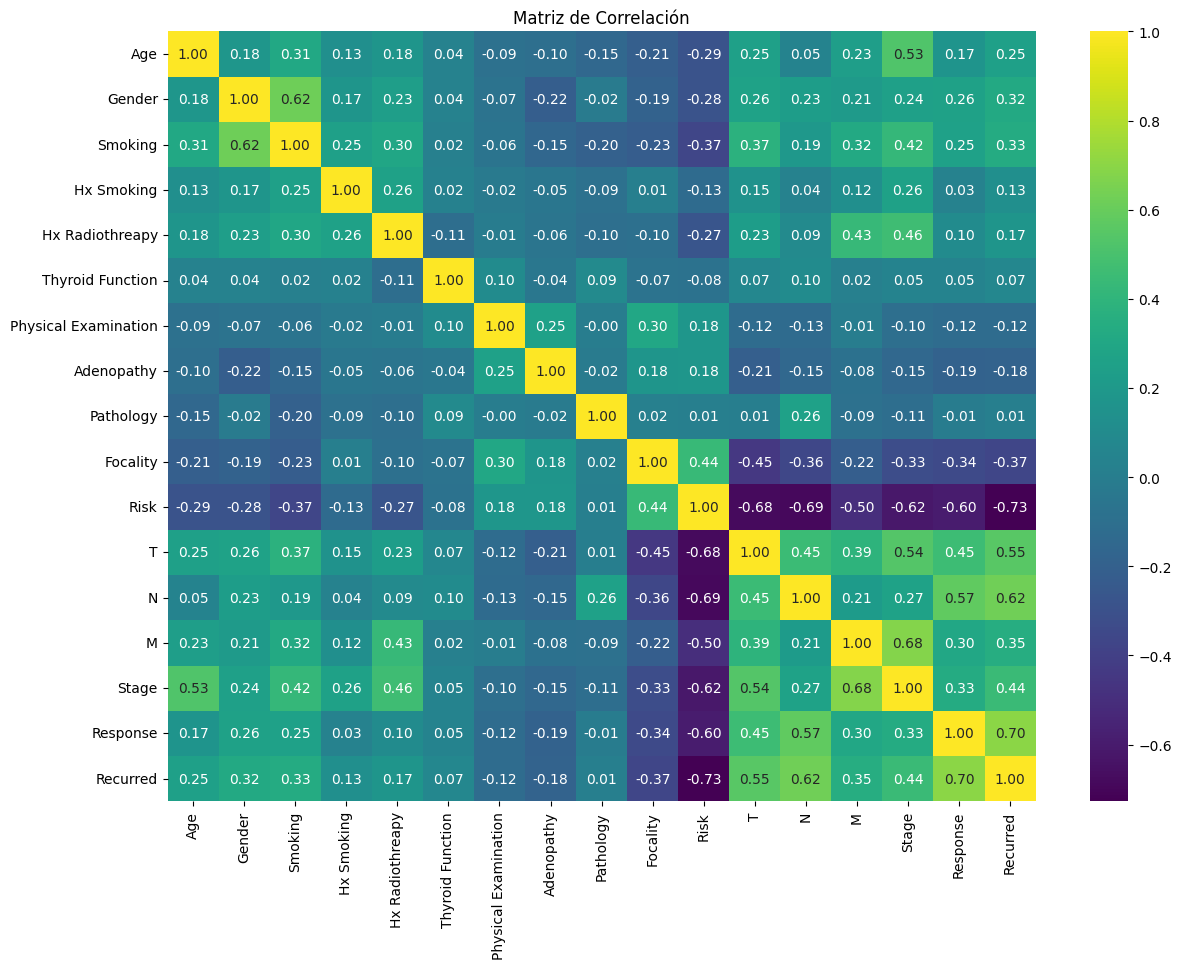

In [60]:
# Codificar variables categóricas para poder calcular la correlación
df_encoded = df_thyroid.copy()
label_encoder = LabelEncoder()

categorical_cols = df_encoded.select_dtypes(include='object').columns
for col in categorical_cols:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Matriz de correlación
correlation_matrix = df_encoded.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Matriz de Correlación')
plt.show()


Las variables que presentan mayor correlación con la recurrencia son: **Riesgo (Risk), Respuesta al tratamiento (Response) y Clasificación de nodos (N)**. Aunque la clasificación del tumor (T) también muestra correlación, se decide incluir **Estado (Stage)** para explorar variables distintas. Y si es **Fumador (Smoking)** 

El mapa de correlación también confirma nuestra hipótesis inicial: **Fumar (Smoking) y el historial de fumar no tienen una relación tan alta con la recurrencia**, lo que indica que otros factores clínicos son más determinantes que el tabaquismo.

##### Graficas EDA Risk

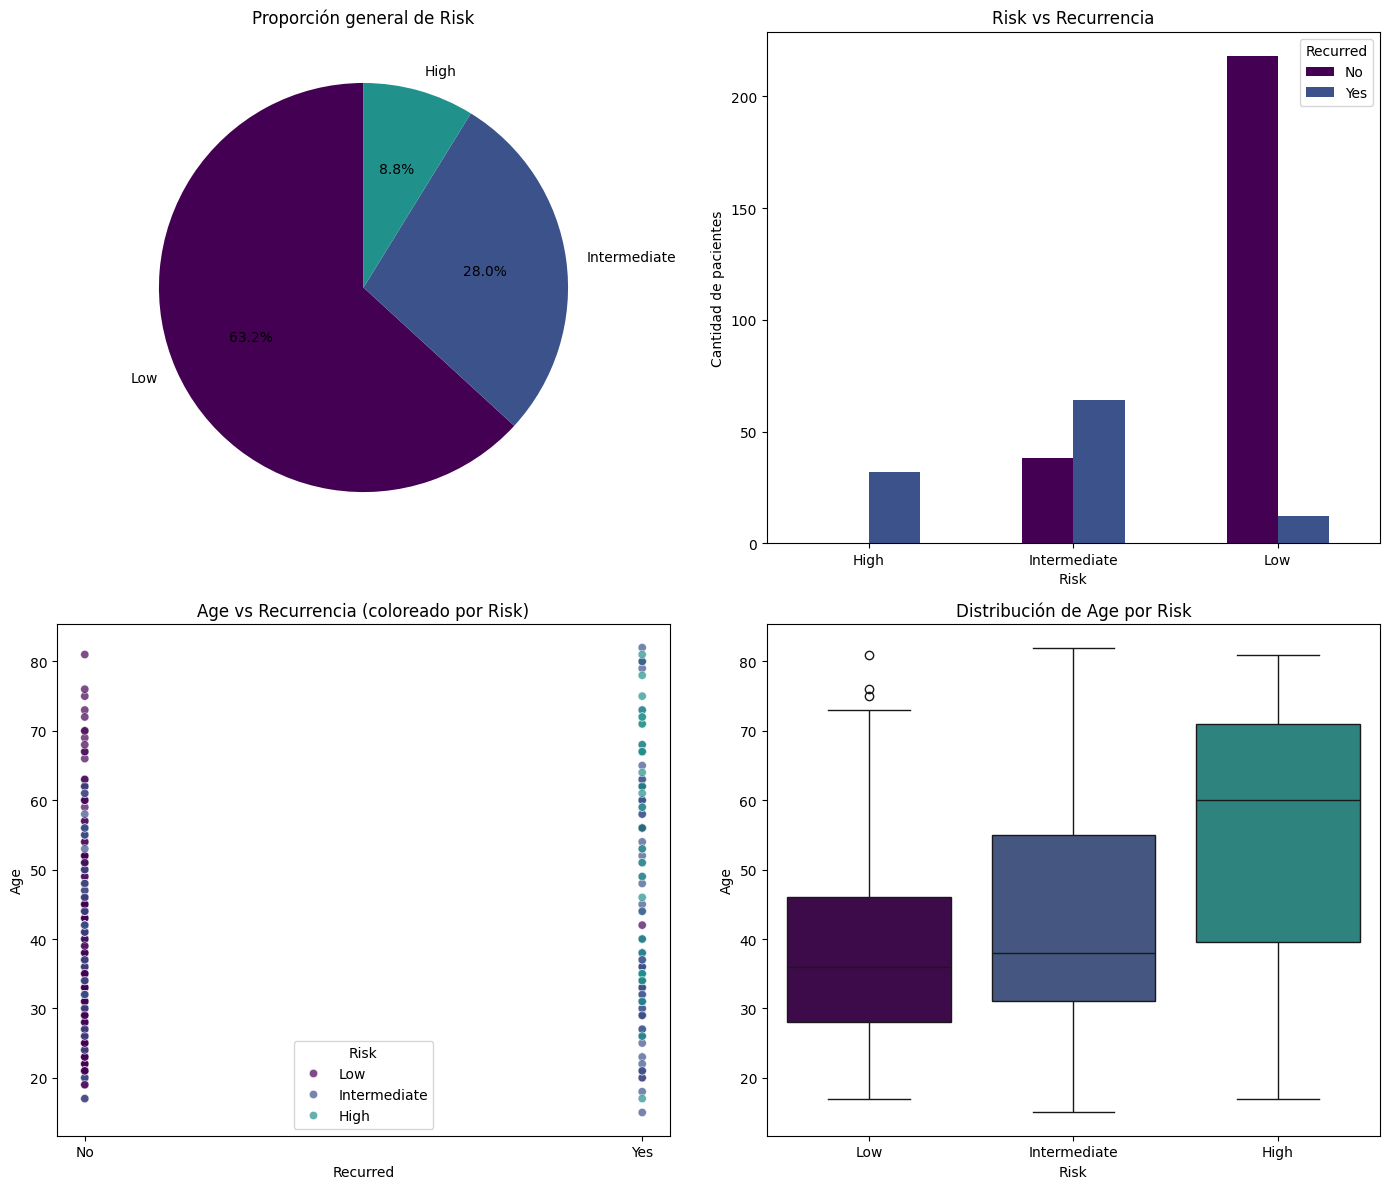

In [62]:
# Grilla 2x2 para el análisis de la variable Risk
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Risk
risk_counts = df_thyroid['Risk'].value_counts()
axes[0, 0].pie(
    risk_counts,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Risk')

# 2. Barras agrupadas - Risk vs Recurred
risk_recurred = pd.crosstab(df_thyroid['Risk'], df_thyroid['Recurred'])
risk_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Risk vs Recurrencia')
axes[0, 1].set_xlabel('Risk')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Risk
risk_categories = df_thyroid['Risk'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Risk',
    data=df_thyroid,
    palette=color_palette[:risk_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Risk)')

# 4. Boxplot - Age por Risk
sns.boxplot(
    x='Risk',
    y='Age',
    hue='Risk',
    data=df_thyroid,
    palette=color_palette[:risk_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Risk')

plt.tight_layout()
plt.show()


##### Graficas EDA Response

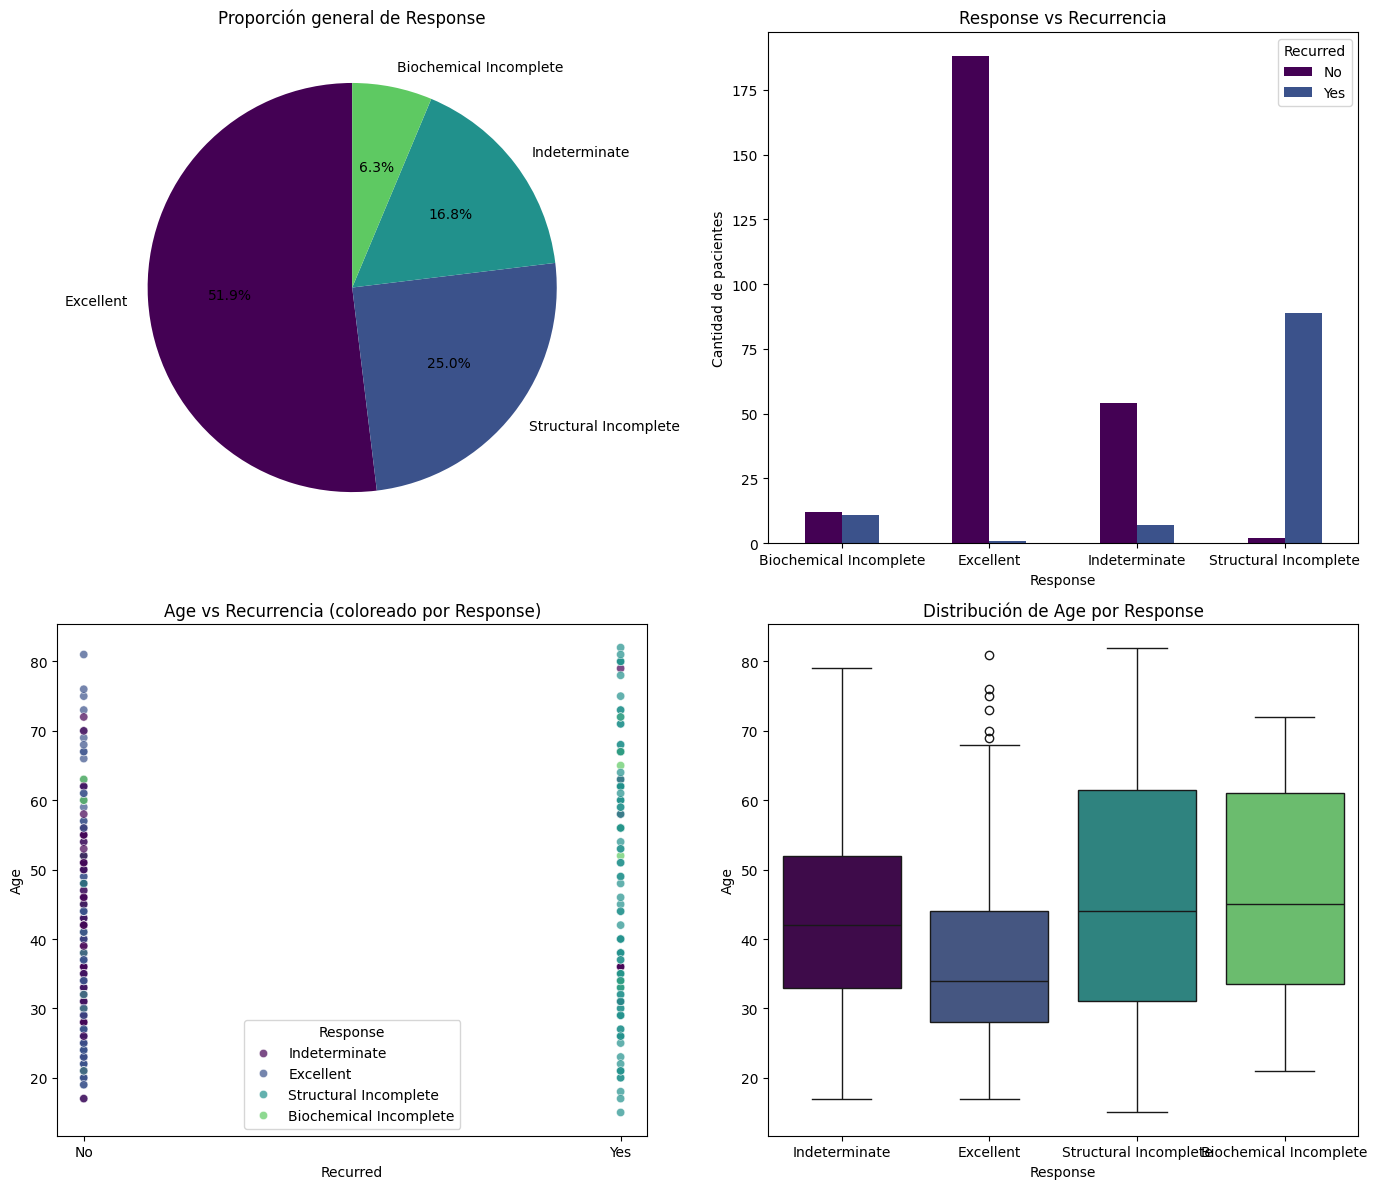

In [63]:
# Grilla 2x2 para el análisis de la variable Response
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Response
response_counts = df_thyroid['Response'].value_counts()
axes[0, 0].pie(
    response_counts,
    labels=response_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Response')

# 2. Barras agrupadas - Response vs Recurred
response_recurred = pd.crosstab(df_thyroid['Response'], df_thyroid['Recurred'])
response_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Response vs Recurrencia')
axes[0, 1].set_xlabel('Response')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Response
response_categories = df_thyroid['Response'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Response',
    data=df_thyroid,
    palette=color_palette[:response_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Response)')

# 4. Boxplot - Age por Response
sns.boxplot(
    x='Response',
    y='Age',
    hue='Response',
    data=df_thyroid,
    palette=color_palette[:response_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Response')

plt.tight_layout()
plt.show()


##### Graficas EDA N (Clasificación de nodos):

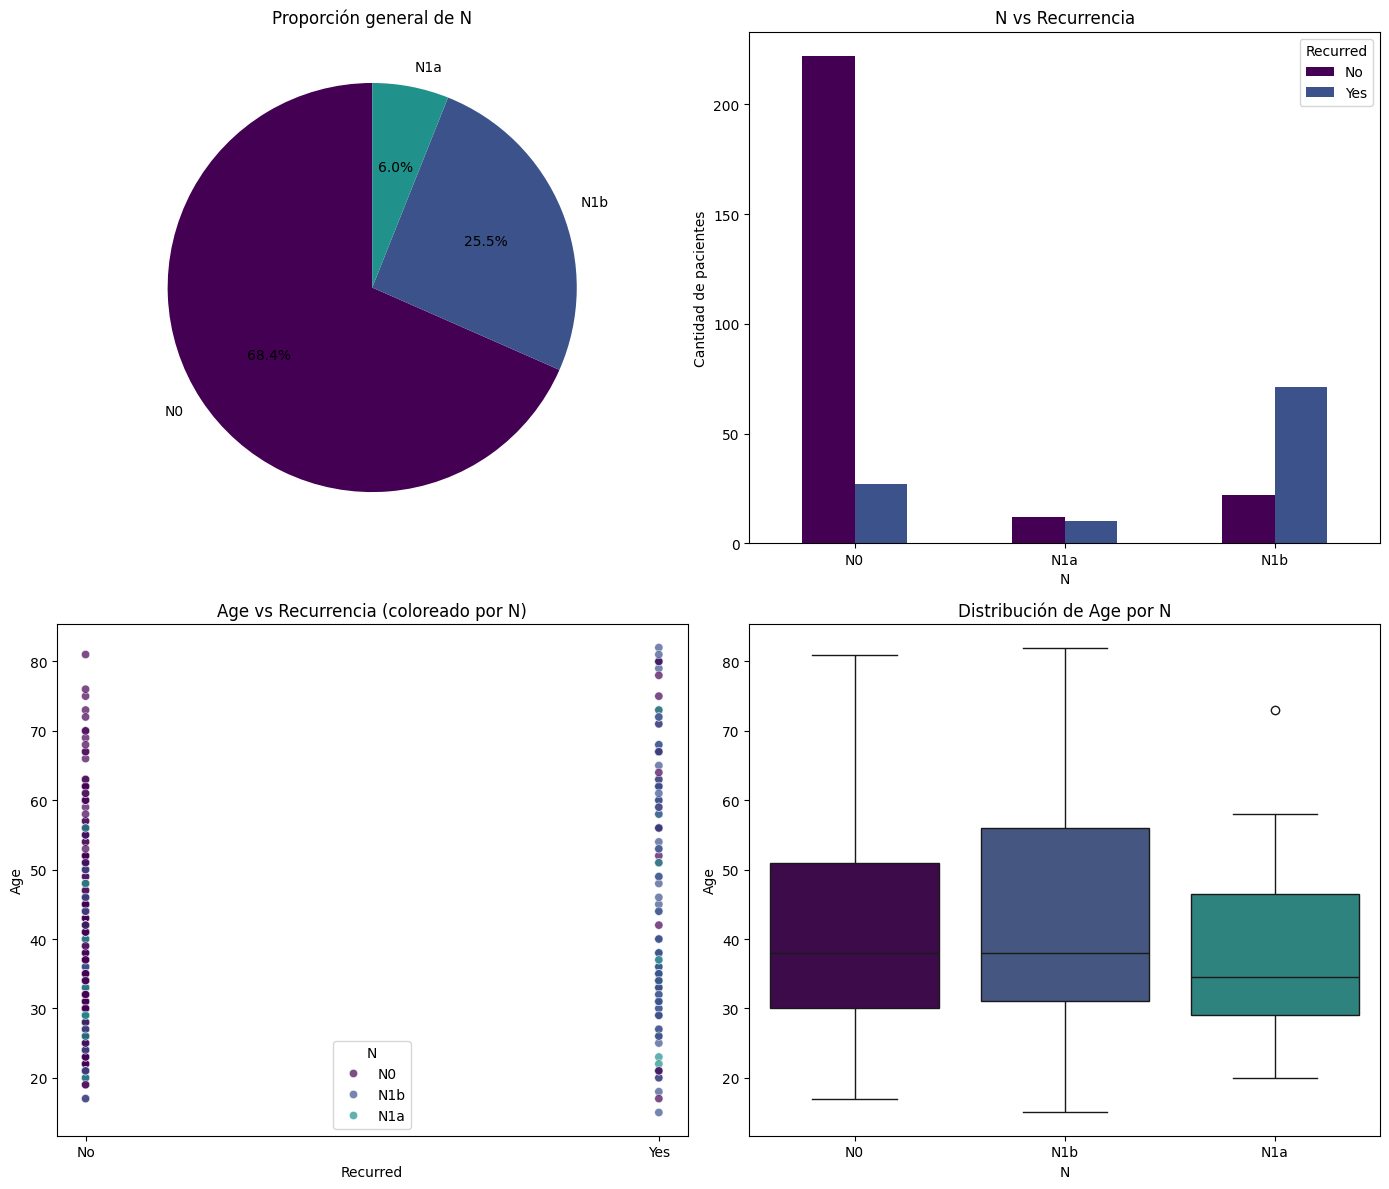

In [64]:
# Grilla 2x2 para el análisis de la variable N
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de N
n_counts = df_thyroid['N'].value_counts()
axes[0, 0].pie(
    n_counts,
    labels=n_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de N')

# 2. Barras agrupadas - N vs Recurred
n_recurred = pd.crosstab(df_thyroid['N'], df_thyroid['Recurred'])
n_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('N vs Recurrencia')
axes[0, 1].set_xlabel('N')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por N
n_categories = df_thyroid['N'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='N',
    data=df_thyroid,
    palette=color_palette[:n_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por N)')

# 4. Boxplot - Age por N
sns.boxplot(
    x='N',
    y='Age',
    hue='N',
    data=df_thyroid,
    palette=color_palette[:n_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por N')

plt.tight_layout()
plt.show()


##### Graficas EDA Stage

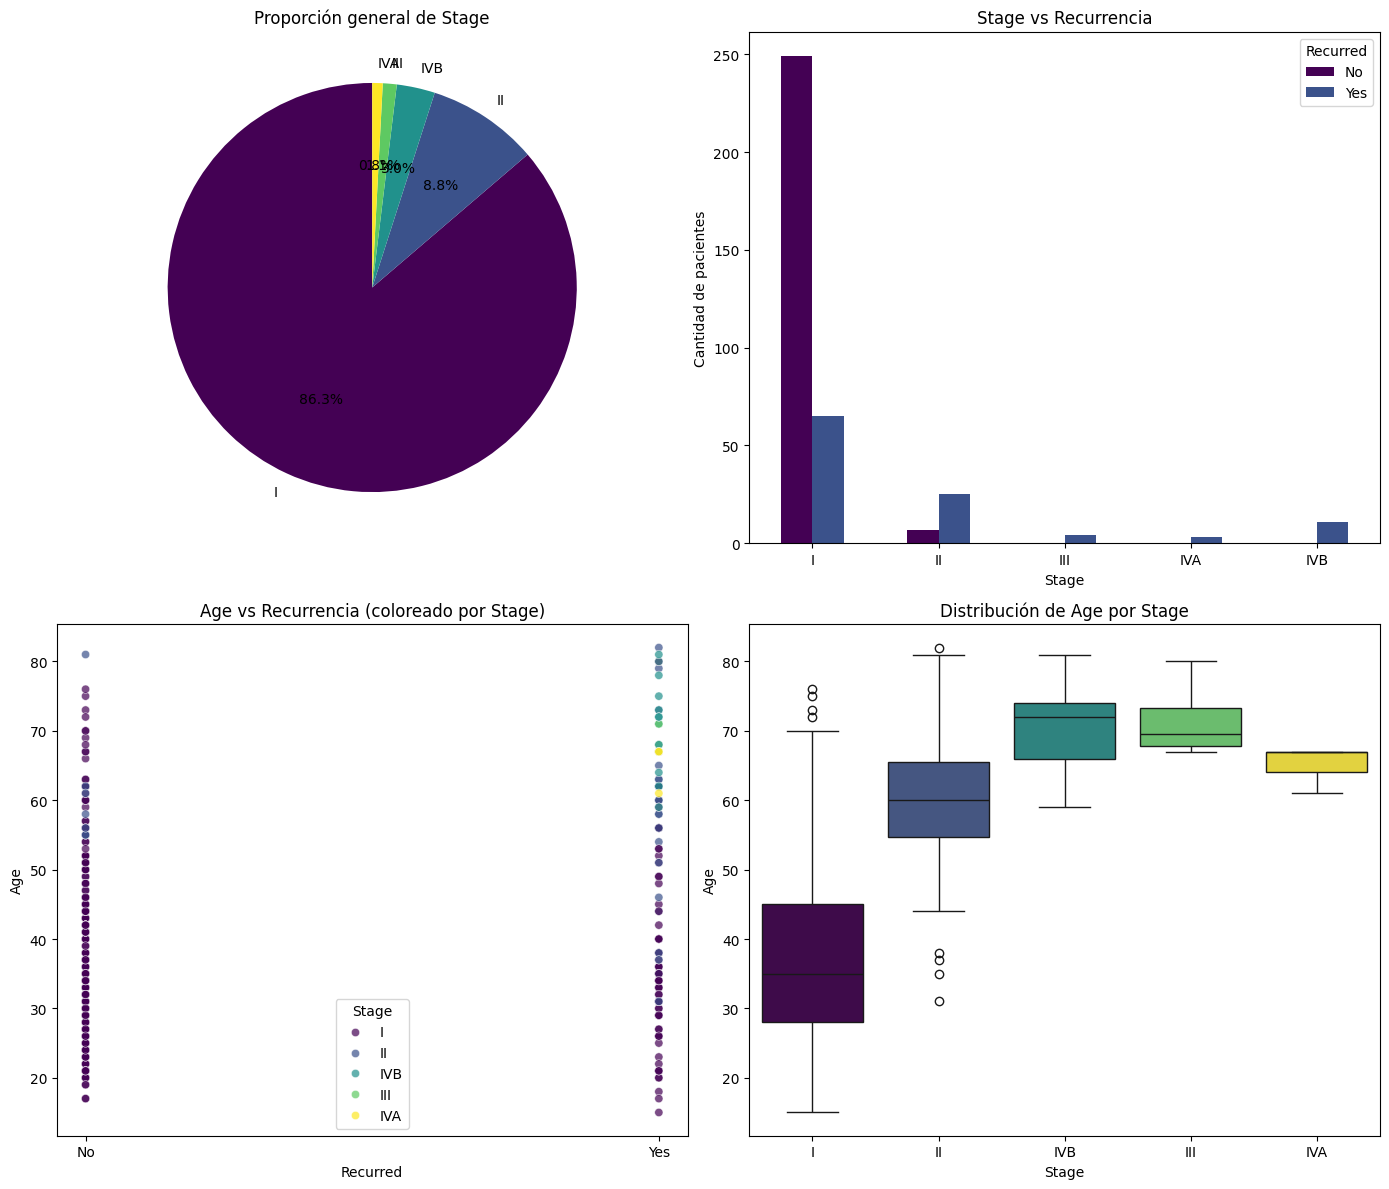

In [65]:
# Grilla 2x2 para el análisis de la variable Stage
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Stage
stage_counts = df_thyroid['Stage'].value_counts()
axes[0, 0].pie(
    stage_counts,
    labels=stage_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Stage')

# 2. Barras agrupadas - Stage vs Recurred
stage_recurred = pd.crosstab(df_thyroid['Stage'], df_thyroid['Recurred'])
stage_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Stage vs Recurrencia')
axes[0, 1].set_xlabel('Stage')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Stage
stage_categories = df_thyroid['Stage'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Stage',
    data=df_thyroid,
    palette=color_palette[:stage_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Stage)')

# 4. Boxplot - Age por Stage
sns.boxplot(
    x='Stage',
    y='Age',
    hue='Stage',
    data=df_thyroid,
    palette=color_palette[:stage_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Stage')

plt.tight_layout()
plt.show()


##### Graficas EDA Smoking

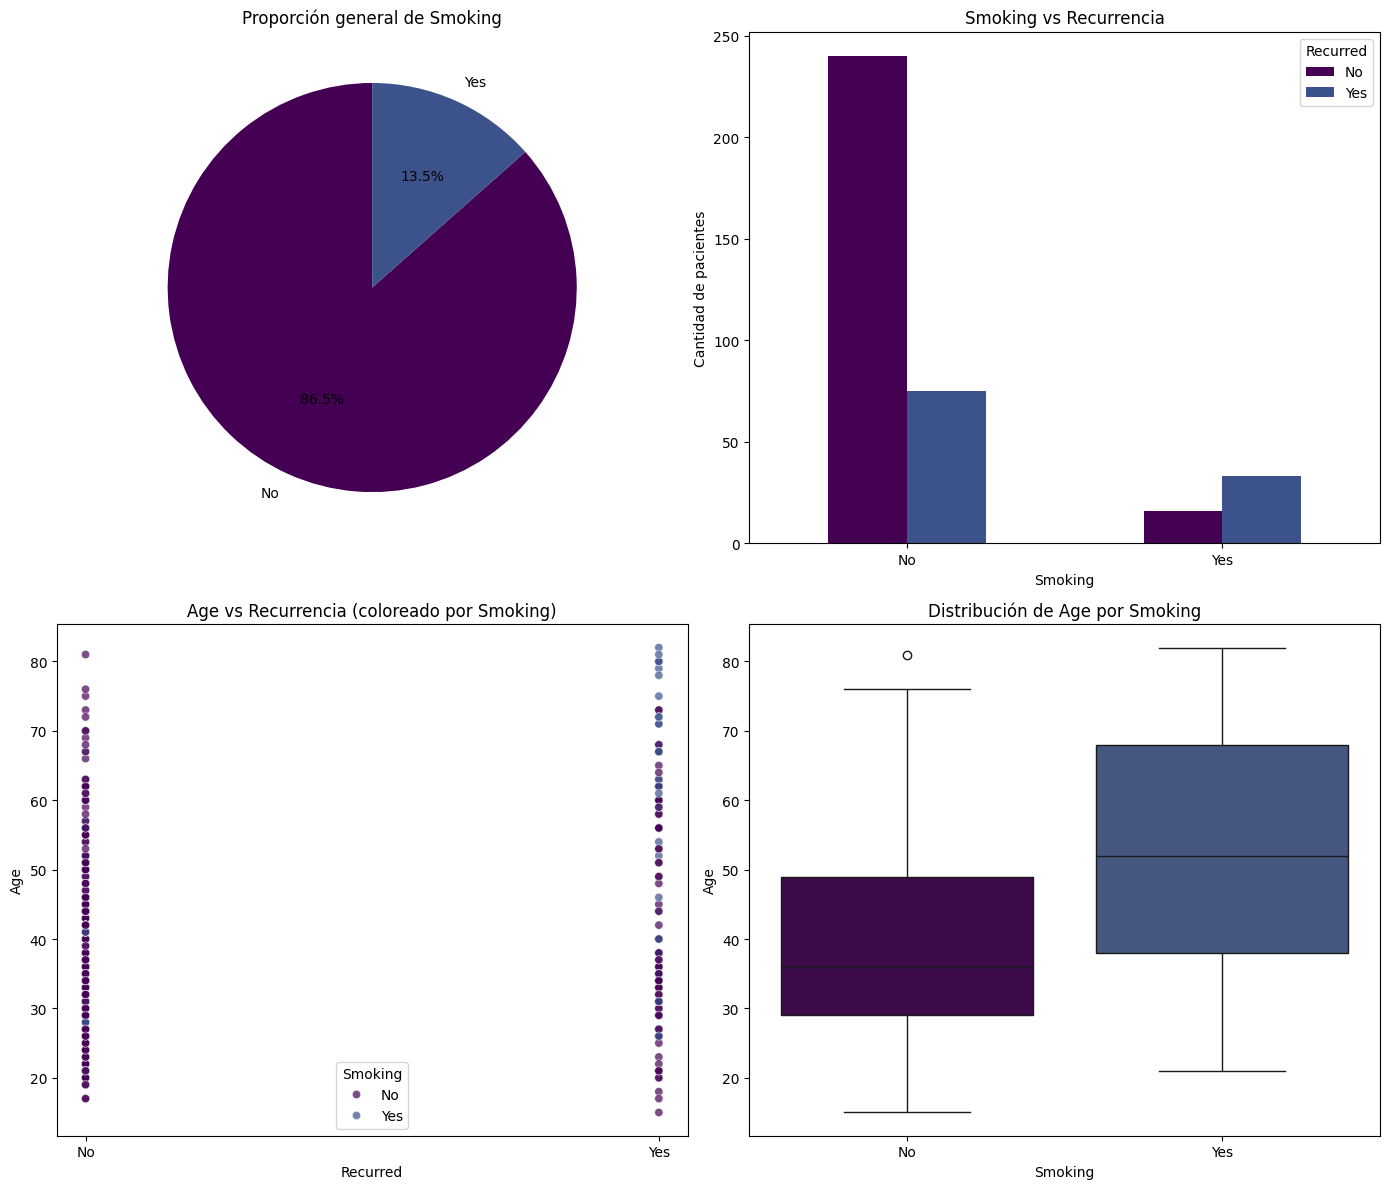

In [66]:
# Grilla 2x2 para el análisis de la variable Smoking
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie chart - Proporción general de Smoking
smoking_counts = df_thyroid['Smoking'].value_counts()
axes[0, 0].pie(
    smoking_counts,
    labels=smoking_counts.index,
    autopct='%1.1f%%',
    colors=color_palette,
    startangle=90
)
axes[0, 0].set_title('Proporción general de Smoking')

# 2. Barras agrupadas - Smoking vs Recurred
smoking_recurred = pd.crosstab(df_thyroid['Smoking'], df_thyroid['Recurred'])
smoking_recurred.plot(kind='bar', ax=axes[0, 1], color=color_palette)
axes[0, 1].set_title('Smoking vs Recurrencia')
axes[0, 1].set_xlabel('Smoking')
axes[0, 1].set_ylabel('Cantidad de pacientes')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Recurred')

# 3. Scatter plot - Age vs Recurred, coloreado por Smoking
smoking_categories = df_thyroid['Smoking'].nunique()
sns.scatterplot(
    x='Recurred',
    y='Age',
    hue='Smoking',
    data=df_thyroid,
    palette=color_palette[:smoking_categories],
    alpha=0.7,
    ax=axes[1, 0]
)
axes[1, 0].set_title('Age vs Recurrencia (coloreado por Smoking)')

# 4. Boxplot - Age por Smoking
sns.boxplot(
    x='Smoking',
    y='Age',
    hue='Smoking',
    data=df_thyroid,
    palette=color_palette[:smoking_categories],
    legend=False,
    ax=axes[1, 1]
)
axes[1, 1].set_title('Distribución de Age por Smoking')

plt.tight_layout()
plt.show()


#### Tecnicas de codificación

| Columna | ¿Tiene Orden Natural? | Cardinalidad | Encoding Recomendado | Justificación |
|---------|----------------------|--------------|----------------------|---------------|
| Gender | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Smoking | No | 2 | Binary Encoding | Solo 2 valores (Sí/No), sin orden |
| Hx Smoking | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Hx Radiotherapy | No | 2 | Binary Encoding | Solo 2 valores, sin orden |
| Thyroid Function | No | 5 | One-Hot Encoding | 5 categorías sin orden natural |
| Physical Examination | No | 5 | One-Hot Encoding | 5 categorías, sin jerarquía |
| Adenopathy | No | 6 | One-Hot Encoding | 6 categorías distintas, sin orden |
| Pathology | No | 4 | One-Hot Encoding | Tipos histológicos sin orden |
| Focality | No | 2 | Binary Encoding | Solo 2 valores (Uni/Multi) |
| Risk | Sí | 3 | Ordinal Encoding | Hay orden: Low < Intermediate < High |
| T | Sí | 7 | Ordinal Encoding | Clasificación TNM con orden natural |
| N | Sí | 3 | Ordinal Encoding | Clasificación TNM con orden natural |
| M | No | 2 | Binary Encoding | Solo 2 valores (Ausencia/Presencia) |
| Stage | Sí | 5 | Ordinal Encoding | Estadios: I < II < III < IV |
| Response | No | 4 | One-Hot Encoding | Tipos de respuesta, sin orden |

#### Escalamiento

Es necesario el escalonado, porque el dataset contiene una única variable numérica continua: **Age (Edad)**, con rango [15-82 años]. Aunque no se detectaron outliers significativos en el análisis del punto 7, el escalado es necesario por dos razones principales**:

1. **Sensibilidad de los algoritmos**: Se entrenarán modelos como KNN y Regresión Logística, que son altamente sensibles a la escala de las variables. Sin escalado, las diferencias en la métrica de distancia estarían dominadas por Age.

2. **Desproporción después del encoding**: Tras el encoding de variables categóricas (Ordinal Encoding para Risk, Stage, T, N; Binary Encoding para Gender, Smoking, etc.), tenemos:
   - **Age**: [15-82] → rango muy grande
   - **Risk (Ordinal)**: [1, 2, 3] → rango pequeño
   - **Gender (Binary)**: [0, 1] → rango muy pequeño
   
   Esta desproporción hace que Age domine completamente el cálculo de distancias en KNN, mientras que las variables categóricas encoded quedan prácticamente ignoradas.

Se elige **StandardScaler** porque:
- **No hay outliers detectados** (por lo tanto, RobustScaler no es necesario)
- Estandariza Age a media=0 y desviación estándar=1
- Transforma el rango [15-82] a aproximadamente [-2.5 a +2.5]
- Es la técnica más adecuada para distribuiciones normales sin outliers extremos
- Mejora la convergencia en algoritmos iterativos (Regresión Logística)
- Mantiene la interpretabilidad de los coeficientes

### **Fase 2 - División de datos y Pipelines**


In [67]:
# Separar variable objetivo del resto de features
X = df_thyroid.drop(columns=['Recurred'])
y = df_thyroid['Recurred']

# Primera partición: 70% train, 30% restante (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Segunda partición: dividir el 30% restante en 15% val y 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} muestras ({X_train.shape[0]/len(df_thyroid):.1%})")
print(f"Validation: {X_val.shape[0]} muestras ({X_val.shape[0]/len(df_thyroid):.1%})")
print(f"Test: {X_test.shape[0]} muestras ({X_test.shape[0]/len(df_thyroid):.1%})")


Train: 254 muestras (69.8%)
Validation: 55 muestras (15.1%)
Test: 55 muestras (15.1%)


Dividimos el dataset en tres conjuntos porque cada uno cumple un propósito distinto dentro del ciclo de vida del modelo:

- **Train (70%):** es el conjunto con el que el modelo aprende, es decir, donde se ajustan sus parámetros internos (pesos, coeficientes, reglas de decisión, etc.).
- **Validation (15%):** se usa durante el desarrollo del modelo para comparar configuraciones y ajustar hiperparámetros (por ejemplo, profundidad de un árbol, número de vecinos en KNN, regularización, etc.), sin tocar el conjunto de test. Nos permite elegir el mejor modelo de forma "justa", sin haber visto los datos finales de evaluación.
- **Test (15%):** se reserva para el final, y se usa una única vez para medir el desempeño real del modelo ya elegido, simulando cómo se comportaría con datos completamente nuevos.

**¿Por qué no basta con solo train/test?**
Si solo tuviéramos train y test, y usáramos el test repetidamente para probar distintas configuraciones de hiperparámetros, estaríamos indirectamente "filtrando" información del test hacia el proceso de entrenamiento (overfitting al conjunto de test). El modelo terminaría luciendo mejor de lo que realmente es, porque fue ajustado (aunque sea indirectamente, por prueba y error) para funcionar bien específicamente en esos datos de test. Al tener un conjunto de validación independiente, el test se mantiene "limpio" y su resultado es una estimación honesta del rendimiento del modelo en producción.



#### Pipeline

In [69]:
# Numérica: escalamiento
numeric_features = ['Age']

# Binarias (2 categorías, sin orden): Binary Encoding
binary_features = ['Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Focality', 'M']

# Nominales (más de 2 categorías, sin orden): One-Hot Encoding
onehot_features = ['Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Response']

# Ordinales (con orden natural): Ordinal Encoding
ordinal_features = ['Risk', 'T', 'N', 'Stage']

# Orden explícito de las categorías ordinales
risk_order = ['Low', 'Intermediate', 'High']
t_order = ['T1a', 'T1b', 'T2', 'T3a', 'T3b', 'T4a', 'T4b']
n_order = ['N0', 'N1a', 'N1b']
stage_order = ['I', 'II', 'III', 'IVA', 'IVB']

In [70]:
# Pipeline numérico: imputación por mediana + escalamiento
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline binario: imputación por moda + Binary Encoding
binary_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', BinaryEncoder())
])

# Pipeline nominal: imputación por moda + One-Hot Encoding
onehot_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Pipeline ordinal: imputación por moda + Ordinal Encoding con orden definido
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[risk_order, t_order, n_order, stage_order]))
])


In [71]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('bin', binary_pipeline, binary_features),
    ('onehot', onehot_pipeline, onehot_features),
    ('ord', ordinal_pipeline, ordinal_features)
])


In [72]:
# Ajustar SOLO con train
X_train_processed = preprocessor.fit_transform(X_train)

# Aplicar la misma transformación ya ajustada a validation y test
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Train shape: {X_train_processed.shape}")
print(f"Validation shape: {X_val_processed.shape}")
print(f"Test shape: {X_test_processed.shape}")


Train shape: (254, 41)
Validation shape: (55, 41)
Test shape: (55, 41)


**Verificación de ausencia de Data Leakage**

En la implementación del preprocesamiento se garantizó que no existe fuga de datos (data leakage) entre los conjuntos de train, validation y test, siguiendo estas reglas:

- El .fit() se ejecutó únicamente sobre X_train: la línea preprocessor.fit_transform(X_train) es la única vez que el ColumnTransformer (y todos los pasos internos: SimpleImputer, StandardScaler, OrdinalEncoder, OneHotEncoder, BinaryEncoder) aprende parámetros a partir de los datos — por ejemplo, la mediana/moda para imputar valores faltantes, la media y desviación estándar de Age para escalar, y las categorías vistas para los encoders.
- Sobre X_val y X_test solo se aplicó .transform(): las líneas preprocessor.transform(X_val) y preprocessor.transform(X_test) reutilizan los parámetros ya aprendidos en el paso anterior, sin recalcular nada nuevo a partir de esos datos.
- No se volvió a llamar fit() ni fit_transform() en ningún punto posterior sobre validation o test, lo cual asegura que esos conjuntos permanecen "no vistos" por el preprocesador durante su ajuste, tal como ocurriría con datos completamente nuevos en producción.

Gracias a este flujo (fit solo en train → transform en train/val/test), ninguna estadística de validation o test (como su media, su moda o sus categorías) influye en la transformación de los datos de entrenamiento, evitando que el modelo obtenga una ventaja artificial al momento de evaluarse.



### **Fase 4 - Modelado: Clasificación (Thyroid Disease Data)**

In [78]:
# Diccionario con los modelos a entrenar
models = {
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

trained_models = {}

# Entrenamiento con barra de progreso (% de modelos completados)
for name, model in tqdm(models.items(), desc='Entrenando modelos'):
    start_time = time.time()
    model.fit(X_train_processed, y_train)
    elapsed_time = time.time() - start_time
    trained_models[name] = model
    print(f"{name} entrenado en {elapsed_time:.4f} segundos")


Entrenando modelos: 100%|██████████| 4/4 [00:00<00:00, 23.68it/s]

KNN entrenado en 0.0124 segundos
Decision Tree entrenado en 0.0085 segundos
Random Forest entrenado en 0.0662 segundos
Gradient Boosting entrenado en 0.0807 segundos


### **Fase 5 - Modelado: Clasificación (Thyroid Disease Data)**

In [79]:
# Calcular métricas de clasificación en train y validation para cada modelo
positive_label = 'Yes'
results = []

for name, model in trained_models.items():
    # Predicciones
    y_train_pred = model.predict(X_train_processed)
    y_val_pred = model.predict(X_val_processed)

    # Índice de la clase positiva para predict_proba (necesario para ROC-AUC)
    positive_idx = list(model.classes_).index(positive_label)
    y_train_proba = model.predict_proba(X_train_processed)[:, positive_idx]
    y_val_proba = model.predict_proba(X_val_processed)[:, positive_idx]

    # Métricas en train
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label=positive_label)
    train_recall = recall_score(y_train, y_train_pred, pos_label=positive_label)
    train_f1 = f1_score(y_train, y_train_pred, pos_label=positive_label)
    train_auc = roc_auc_score(y_train.map({'No': 0, 'Yes': 1}), y_train_proba)

    # Métricas en validation
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, pos_label=positive_label)
    val_recall = recall_score(y_val, y_val_pred, pos_label=positive_label)
    val_f1 = f1_score(y_val, y_val_pred, pos_label=positive_label)
    val_auc = roc_auc_score(y_val.map({'No': 0, 'Yes': 1}), y_val_proba)

    results.append({
        'Model': name,
        'Train Accuracy': train_accuracy, 'Val Accuracy': val_accuracy,
        'Train Precision': train_precision, 'Val Precision': val_precision,
        'Train Recall': train_recall, 'Val Recall': val_recall,
        'Train F1': train_f1, 'Val F1': val_f1,
        'Train AUC': train_auc, 'Val AUC': val_auc
    })

results_df = pd.DataFrame(results).round(4)
results_df


,Model,Train Accuracy,Val Accuracy,Train Precision,Val Precision,Train Recall,Val Recall,Train F1,Val F1,Train AUC,Val AUC
0,KNN,0.937,0.8727,0.9683,0.9167,0.8133,0.6471,0.8841,0.7586,0.9864,0.9745
1,Decision Tree,1.000,0.9091,1.0000,0.8000,1.0000,0.9412,1.0000,0.8649,1.0000,0.9180
2,Random Forest,1.000,0.9636,1.0000,0.9412,1.0000,0.9412,1.0000,0.9412,1.0000,0.9923
3,Gradient Boosting,1.000,0.9091,1.0000,0.8000,1.0000,0.9412,1.0000,0.8649,1.0000,0.9923
